In [319]:
import sys, os 
import geopandas as gpd 
import numpy as np
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats_na_dropped.geojson')
gdf = gpd.read_file(data_path)

In [320]:
from sklearn.model_selection import train_test_split

features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std',  'eccentricity', 'solidity',
            'mean_intensity', 'perimeter', 'compactness', 'shape_index','area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']

def load_train_test_data(raw_target):
    if raw_target == 'CODIGO_GROUP_2':
        label_map = {
            '0' : 'Building',
            '11' : 'Urban',
            '12' : 'Highway',
            '21' : 'Seasonal crops',
            '22' : 'Permanent crops',
            '23' : 'Pasture',
            '31' : 'Forest',
            '32' : 'Grassland',
            '33' : 'Bare areas',
            '51' : 'Water'
        }
    elif raw_target == 'CODIGO_GROUP_1':
        label_map = {
            '0' : 'Building',
            '1' : 'Artificial Surfaces',
            '2' : 'Agriculture',
            '3' : 'Forest',
            '4' : 'Wetlands',
            '5' : 'Water'
        }
        
    train_gdf, test_gdf = train_test_split(gdf, test_size=0.2, random_state=42, stratify=gdf[raw_target])

    train_gdf['OBSERV_GROUP'] = train_gdf[raw_target].replace(label_map)

    test_gdf['OBSERV_GROUP'] = test_gdf[raw_target].replace(label_map)

    X_train = train_gdf[features]
    y_train = train_gdf['OBSERV_GROUP']
    X_test = test_gdf[features]
    y_test = test_gdf['OBSERV_GROUP']

    labels = train_gdf['OBSERV_GROUP'].unique()
    print("train set distribution:")
    print(train_gdf['OBSERV_GROUP'].value_counts())
    print("\n test distribution:")
    print(test_gdf['OBSERV_GROUP'].value_counts())
    return X_train, X_test, y_train, y_test, labels

In [321]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import pandas as pd 
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


def plot_comparison(models_info, group='CODIGO-GROUP-1'):
    model_names = [m['name'] for m in models_info]
    train_scores = [m['train_score'] for m in models_info]
    val_scores = [m['val_score'] for m in models_info]
    test_scores = [m['test_score'] for m in models_info]

    x = np.arange(len(model_names))
    width = 0.25

    colors_train = '#1f77b4'
    colors_val = '#ff7f0e'
    colors_test = '#2ca02c'

    fig, ax = plt.subplots(figsize=(14, 7))

    bars1 = ax.bar(x - width, train_scores, width, label='Train', color=colors_train, alpha=0.85)
    bars2 = ax.bar(x, val_scores, width, label='Val', color=colors_val, alpha=0.85)
    bars3 = ax.bar(x + width, test_scores, width, label='Test', color=colors_test, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('F1 Macro Average Score', fontsize=12)
    ax.set_title(f'Train, Val, Test F1 Macro Scores by Model : {group}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2.0, height + 0.02,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

def get_dummy_f1_scores(X_train, y_train, X_test, y_test):
    strategies = ['most_frequent', 'stratified', 'uniform']
    f1_scores = {}

    for strategy in strategies:
        dummy = DummyClassifier(strategy=strategy, random_state=42)
        dummy.fit(X_train, y_train)
        y_pred = dummy.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=1)
        f1_scores[strategy] = report['macro avg']['f1-score']

    return f1_scores

def compute_accuracy(classifier, X_test, y_test,labels, experiment_name=''):
    y_pred = classifier.best_estimator_.predict(X_test)
    testing_classification_accuracy_dict= classification_report(y_test, y_pred,output_dict=True, zero_division=1) # zero_division=1 to handle any zero division cases
    testing_classification_accuracy= classification_report(y_test, y_pred, zero_division=1) # zero_division=1 to handle any zero division cases

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    cm_norm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')

    cmd_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.4})
    cmd.plot(ax=ax[0], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    cmd_norm.plot(ax=ax[1], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    ax[0].set_title(f'{experiment_name} C M')
    ax[1].set_title(f'{experiment_name} Normalized C M')
    plt.show()
    
    print("\n Best Hyperparameters using cv:", classifier.best_params_)
    print("\n Best f1 score using cv:", classifier.best_score_)
    print("\n best f1 val score", classifier.cv_results_['mean_test_score'][int(classifier.best_index_)])
    print("\n best f1 train score", classifier.cv_results_['mean_train_score'][int(classifier.best_index_)])

    return testing_classification_accuracy, testing_classification_accuracy_dict

def rf_hyperparameter_tuning(X_train, y_train):
    param_dist = {
        'n_estimators': randint(50, 150),
        'max_depth': [5,10,15,20,25,30, None], # default is None
        'criterion' : ['gini', 'entropy', 'log_loss'],  # default is gini
        'min_samples_leaf': randint(1,10), # default value is 1 
        'min_samples_split': randint(2,7), # default value is 2
        'max_leaf_nodes' : [None, 10,30 ], # default is None 
        'class_weight':['balanced','balanced_subsample', None], # source for this hyper param tuning : https://www.geeksforgeeks.org/machine-learning/bagging-and-random-forest-for-imbalanced-classification/
    } # https://www.geeksforgeeks.org/machine-learning/how-to-solve-overfitting-in-random-forest-in-python-sklearn/ 

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # https://medium.com/@aditib259/a-comprehensive-guide-to-hyperparameter-tuning-in-machine-learning-dd9bb8072d02 

    grid_search_rf = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_distributions=param_dist,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        scoring='f1_macro',
        return_train_score=True,
        random_state=42,
    )
    grid_search_rf.fit(X_train, y_train)
    return grid_search_rf


def plot_rf_feature_importances(model):
    mdi_importances = pd.Series(
        model.feature_importances_, index=features
    ).sort_values(ascending=True)
    ax = mdi_importances.plot.barh()
    ax.set_title("Random Forest Feature Importances (MDI)")
    ax.figure.tight_layout()
    return mdi_importances

def run_svm_hyperparameter_tuning(X_train, y_train, X_test, y_test, labels, experiment_name='SVM', return_scaled_data=False):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    param_dist = {
        'C': randint(1, 10),
        'class_weight': [None, 'balanced'],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'poly', 'sigmoid']
    }

    cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    random_search_cv = RandomizedSearchCV(
        estimator=SVC(random_state=42),
        param_distributions=param_dist,
        cv=cv_svm,
        n_jobs=-1,
        verbose=0,
        scoring='f1_macro',
        return_train_score=True,
        random_state=42,
    )
    random_search_cv.fit(X_train_scaled, y_train)

    testing_classification_accuracy, ac_dict = compute_accuracy(random_search_cv, X_test_scaled, y_test,labels, experiment_name=experiment_name)
    
    if return_scaled_data:
        return random_search_cv, testing_classification_accuracy, X_train_scaled, X_test_scaled
    
    return random_search_cv , testing_classification_accuracy, ac_dict


## Codigo Group 2

In [322]:
X_train, X_test, y_train, y_test, labels = load_train_test_data('CODIGO_GROUP_2')

train set distribution:
OBSERV_GROUP
Building           532
Pasture            404
Forest             186
Urban              124
Bare areas         123
Permanent crops     46
Seasonal crops      34
Water               32
Grassland           32
Highway             30
Name: count, dtype: int64

 test distribution:
OBSERV_GROUP
Building           133
Pasture            101
Forest              47
Bare areas          31
Urban               31
Permanent crops     11
Highway              8
Water                8
Grassland            8
Seasonal crops       8
Name: count, dtype: int64


## Normal RF 

Fitting 5 folds for each of 10 candidates, totalling 50 fits


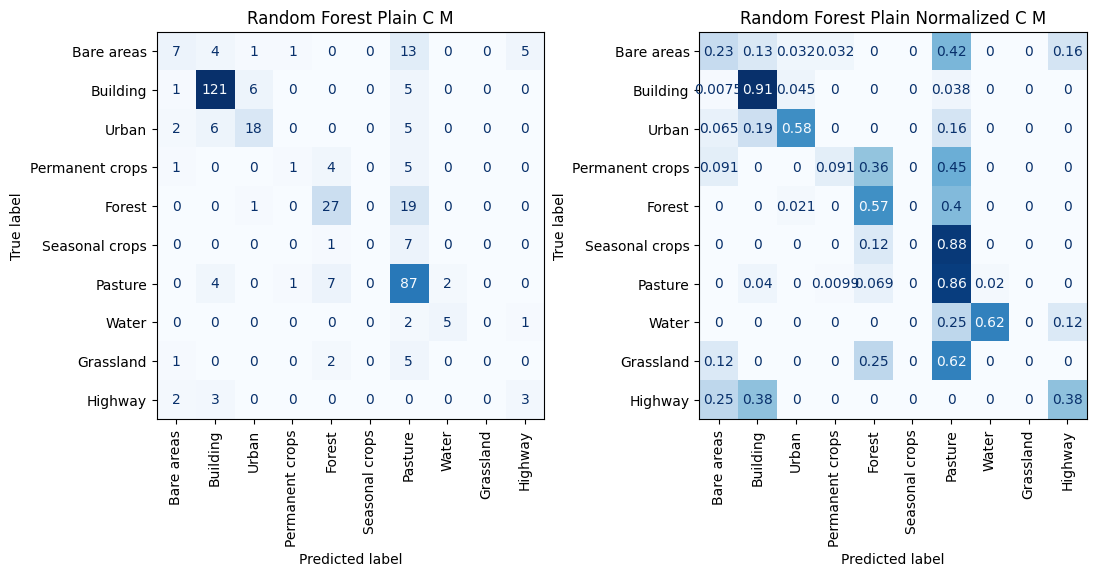


 Best Hyperparameters using cv: {'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 20, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 108}

 Best f1 score using cv: 0.45739727482103276

 best f1 val score 0.45739727482103276

 best f1 train score 0.9989561503279398
f1-macro-avg-test 0.4310575518722485
Testing Classification Report :
                  precision    recall  f1-score   support

     Bare areas       0.50      0.23      0.31        31
       Building       0.88      0.91      0.89       133
         Forest       0.66      0.57      0.61        47
      Grassland       1.00      0.00      0.00         8
        Highway       0.33      0.38      0.35         8
        Pasture       0.59      0.86      0.70       101
Permanent crops       0.33      0.09      0.14        11
 Seasonal crops       1.00      0.00      0.00         8
          Urban       0.69      0.58      0.63        31
          Water       0.71    

In [323]:
random_search_cv_rf_normal= rf_hyperparameter_tuning(X_train, y_train)

testing_classification_accuracy_rf_normal, ac_dict_rf_normal = compute_accuracy(random_search_cv_rf_normal, X_test, y_test, labels, experiment_name='Random Forest Plain')

f1_macro_rf_normal_test = ac_dict_rf_normal['macro avg']['f1-score']

f1_macro_rf_normal_val_cv = random_search_cv_rf_normal.cv_results_['mean_test_score'][int(random_search_cv_rf_normal.best_index_)]
f1_macro_rf_normal_train_cv = random_search_cv_rf_normal.cv_results_['mean_train_score'][int(random_search_cv_rf_normal.best_index_)]


print("f1-macro-avg-test", f1_macro_rf_normal_test)

print("Testing Classification Report :\n", testing_classification_accuracy_rf_normal)

## Normal SVM 

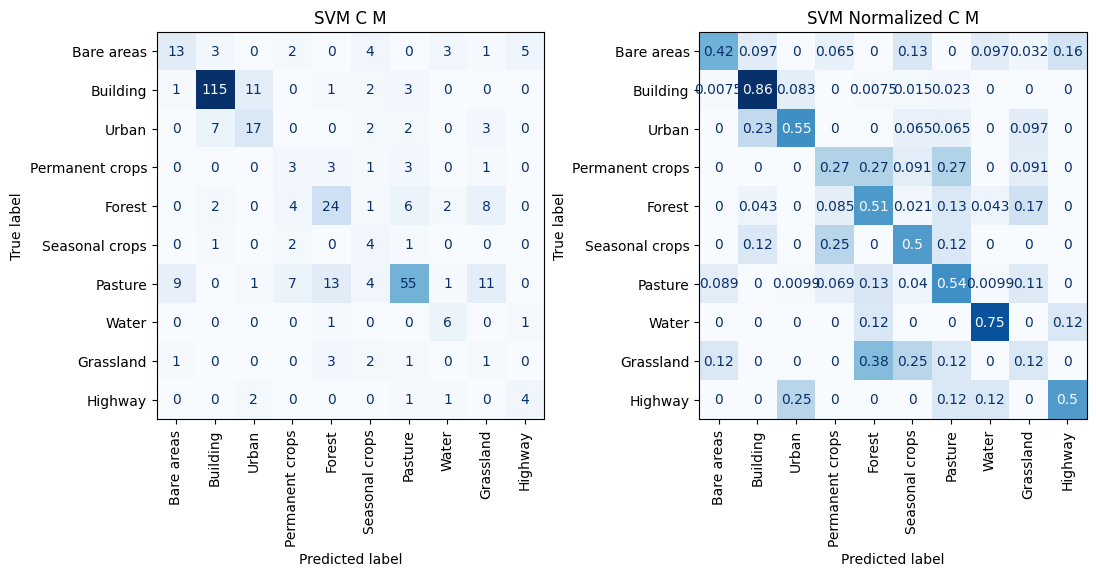


 Best Hyperparameters using cv: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}

 Best f1 score using cv: 0.46089020728373997

 best f1 val score 0.46089020728373997

 best f1 train score 0.7109450237610642
f1-macro-avg-test 0.4629007617782612
Testing Classification Report :
                  precision    recall  f1-score   support

     Bare areas       0.54      0.42      0.47        31
       Building       0.90      0.86      0.88       133
         Forest       0.53      0.51      0.52        47
      Grassland       0.04      0.12      0.06         8
        Highway       0.40      0.50      0.44         8
        Pasture       0.76      0.54      0.64       101
Permanent crops       0.17      0.27      0.21        11
 Seasonal crops       0.20      0.50      0.29         8
          Urban       0.55      0.55      0.55        31
          Water       0.46      0.75      0.57         8

       accuracy                           0.63       386
      macro a

In [324]:
best_model_svm_normal_cv, testing_classification_accuracy_svm_normal, ac_dict_svm_normal = run_svm_hyperparameter_tuning(X_train, y_train, X_test, y_test, labels)


f1_macro_svm_normal_test = ac_dict_svm_normal['macro avg']['f1-score']
f1_macro_svm_normal_val_cv = best_model_svm_normal_cv.cv_results_['mean_test_score'][int(best_model_svm_normal_cv.best_index_)]
f1_macro_svm_normal_train_cv = best_model_svm_normal_cv.cv_results_['mean_train_score'][int(best_model_svm_normal_cv.best_index_)]


print("f1-macro-avg-test", f1_macro_svm_normal_test)

print("Testing Classification Report :\n", testing_classification_accuracy_svm_normal)

#### test with random forest imbalance handling 

Fitting 5 folds for each of 10 candidates, totalling 50 fits


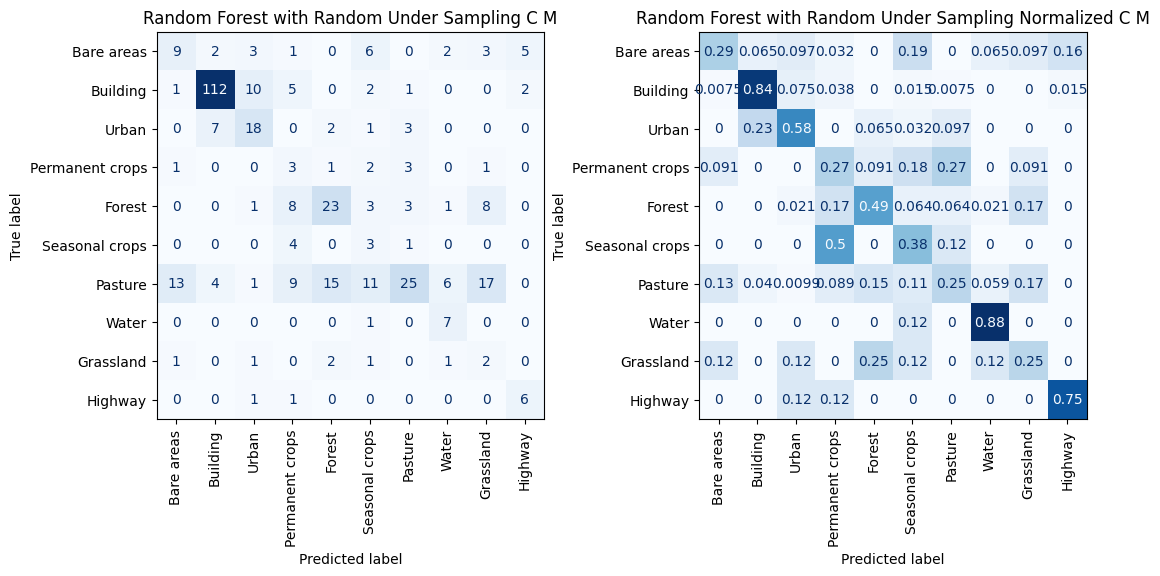


 Best Hyperparameters using cv: {'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 20, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 108}

 Best f1 score using cv: 0.45182296461708227

 best f1 val score 0.45182296461708227

 best f1 train score 0.9991663048198003
Testing Classification Report:
 ('                 precision    recall  f1-score   support\n\n     Bare areas       0.36      0.29      0.32        31\n       Building       0.90      0.84      0.87       133\n         Forest       0.53      0.49      0.51        47\n      Grassland       0.06      0.25      0.10         8\n        Highway       0.46      0.75      0.57         8\n        Pasture       0.69      0.25      0.36       101\nPermanent crops       0.10      0.27      0.14        11\n Seasonal crops       0.10      0.38      0.16         8\n          Urban       0.51      0.58      0.55        31\n          Water       0.41      0.88      0.56         

In [325]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

random_search_cv = rf_hyperparameter_tuning(X_train_resampled, y_train_resampled)

testing_classification_accuracy = compute_accuracy(random_search_cv, X_test, y_test,labels, experiment_name='Random Forest with Random Under Sampling')

print("Testing Classification Report:\n", testing_classification_accuracy)


### SMOTE

https://medium.com/sfu-cspmp/surviving-in-a-random-forest-with-imbalanced-datasets-b98b963d52eb 

SMOTE (Synthetic Minority Oversampling Technique) is one of the oversampling techniques that use a minority class to generate synthetic samples. In consequence, it overcomes the overfitting problem raised by random oversampling. SMOTE works by generating instances that are close in feature space, using interpolation between positive cases that are close to each other. It randomly selects a minority class instance and finds its nearest neighbour. Then it creates synthetic models by randomly choosing one of the neighbours and forms a line segment in the feature space. 

Fitting 5 folds for each of 10 candidates, totalling 50 fits


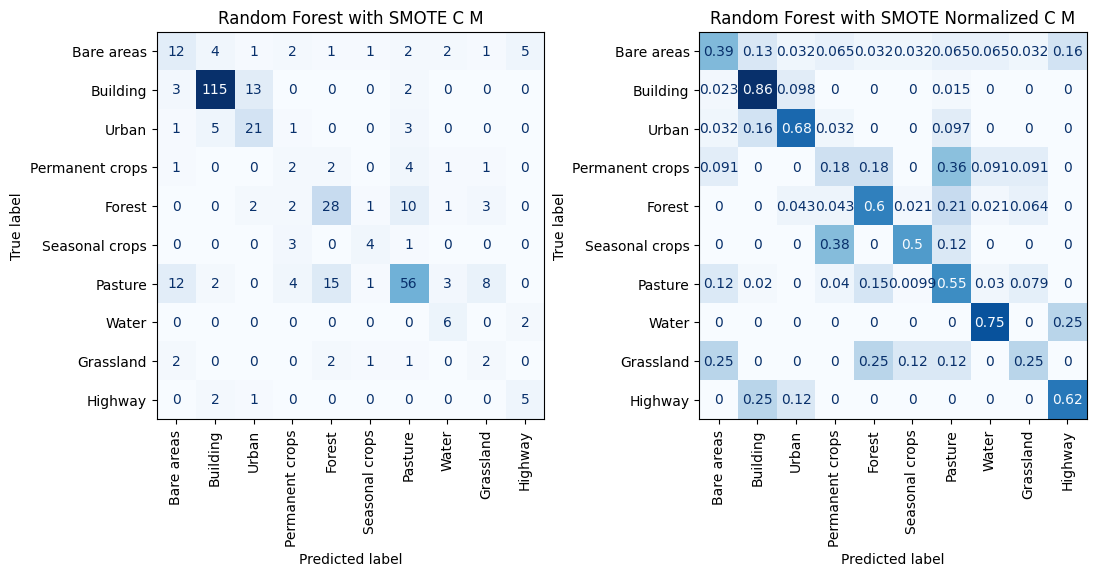


 Best Hyperparameters using cv: {'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 20, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 108}

 Best f1 score using cv: 0.9011247639714632

 best f1 val score 0.9011247639714632

 best f1 train score 0.9997181990685963
f1-macro-avg-test 0.49940560013468893
Testing Classification Report:
                  precision    recall  f1-score   support

     Bare areas       0.39      0.39      0.39        31
       Building       0.90      0.86      0.88       133
         Forest       0.58      0.60      0.59        47
      Grassland       0.13      0.25      0.17         8
        Highway       0.42      0.62      0.50         8
        Pasture       0.71      0.55      0.62       101
Permanent crops       0.14      0.18      0.16        11
 Seasonal crops       0.50      0.50      0.50         8
          Urban       0.55      0.68      0.61        31
          Water       0.46      

In [326]:
from imblearn.over_sampling import SMOTE # source : https://medium.com/sfu-cspmp/surviving-in-a-random-forest-with-imbalanced-datasets-b98b963d52eb

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

random_search_cv_rf_with_smote= rf_hyperparameter_tuning(X_train_resampled, y_train_resampled)

testing_classification_accuracy_rf_with_smote, ac_dict_rf_with_smote = compute_accuracy(random_search_cv_rf_with_smote, X_test, y_test,labels, experiment_name='Random Forest with SMOTE')

f1_macro_rf_with_smote_test = ac_dict_rf_with_smote['macro avg']['f1-score']

f1_macro_rf_with_smote_val_cv = random_search_cv_rf_with_smote.cv_results_['mean_test_score'][int(random_search_cv_rf_with_smote.best_index_)]
f1_macro_rf_with_smote_train_cv = random_search_cv_rf_with_smote.cv_results_['mean_train_score'][int(random_search_cv_rf_with_smote.best_index_)]


print("f1-macro-avg-test", f1_macro_rf_with_smote_test)

print("Testing Classification Report:\n", testing_classification_accuracy_rf_with_smote)

# _ = plot_rf_feature_importances(random_search_cv_rf_with_smote.best_estimator_)

### SVM with smote 

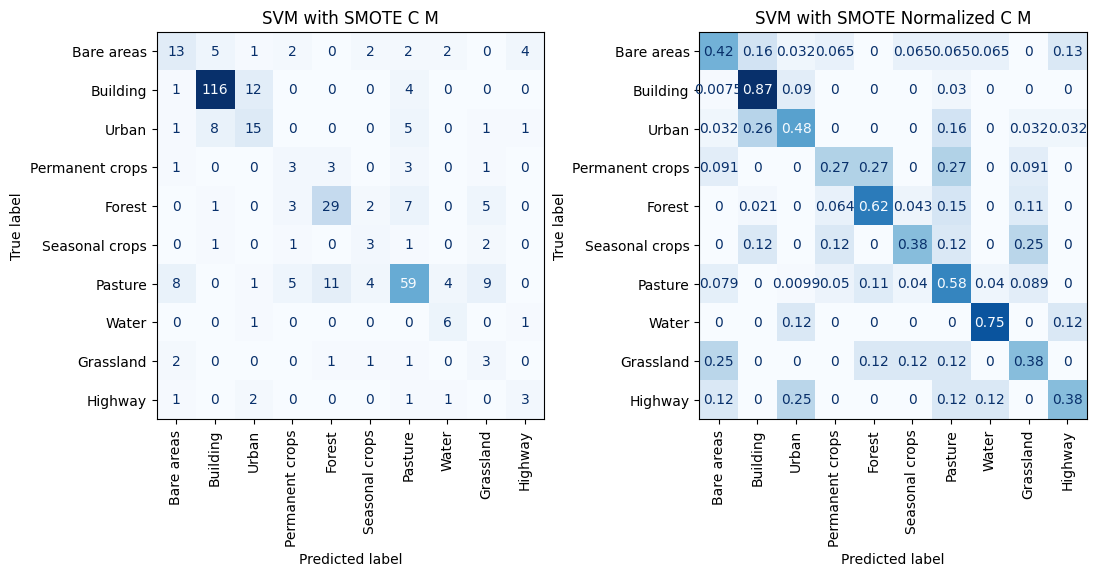


 Best Hyperparameters using cv: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}

 Best f1 score using cv: 0.8630281059747338

 best f1 val score 0.8630281059747338

 best f1 train score 0.901547935913378
f1-macro-avg-test 0.4753187501859342
Testing Classification Report :
                  precision    recall  f1-score   support

     Bare areas       0.48      0.42      0.45        31
       Building       0.89      0.87      0.88       133
         Forest       0.66      0.62      0.64        47
      Grassland       0.14      0.38      0.21         8
        Highway       0.33      0.38      0.35         8
        Pasture       0.71      0.58      0.64       101
Permanent crops       0.21      0.27      0.24        11
 Seasonal crops       0.25      0.38      0.30         8
          Urban       0.47      0.48      0.48        31
          Water       0.46      0.75      0.57         8

       accuracy                           0.65       386
      macro avg 

In [327]:
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

best_model_svm_with_smote, testing_classification_accuracy_svm_with_smote, ac_dict_svm_with_smote = run_svm_hyperparameter_tuning(X_train_resampled, y_train_resampled, X_test, y_test,labels, experiment_name='SVM with SMOTE')

f1_macro_svm_with_smote_test = ac_dict_svm_with_smote['macro avg']['f1-score']
f1_macro_svm_with_smote_val_cv = best_model_svm_with_smote.cv_results_['mean_test_score'][int(best_model_svm_with_smote.best_index_)]
f1_macro_svm_with_smote_train_cv = best_model_svm_with_smote.cv_results_['mean_train_score'][int(best_model_svm_with_smote.best_index_)]


print("f1-macro-avg-test", f1_macro_svm_with_smote_test)

print("Testing Classification Report :\n", testing_classification_accuracy_svm_with_smote)

In [328]:
models_info = [
    {
        "name": "RF Normal",
        "model": random_search_cv_rf_normal.best_estimator_,
        "train_score": f1_macro_rf_normal_train_cv,
        "val_score": f1_macro_rf_normal_val_cv,
        "test_score": f1_macro_rf_normal_test,
    },
    {
        "name": "RF with SMOTE",
        "model": random_search_cv_rf_with_smote.best_estimator_,
        "train_score": f1_macro_rf_with_smote_train_cv,
        "val_score": f1_macro_rf_with_smote_val_cv,
        "test_score": f1_macro_rf_with_smote_test,
    },
    {
        "name": "SVM Normal",
        "model": best_model_svm_normal_cv.best_estimator_,
        "scaler": StandardScaler(),
        "train_score": f1_macro_svm_normal_train_cv,
        "val_score": f1_macro_svm_normal_val_cv,
        "test_score": f1_macro_svm_normal_test,
    },
    {
        "name": "SVM with SMOTE",
        "model": best_model_svm_with_smote.best_estimator_,
        "scaler": StandardScaler(),
        "train_score": f1_macro_svm_with_smote_train_cv,
        "val_score": f1_macro_svm_with_smote_val_cv,
        "test_score": f1_macro_svm_with_smote_test,
    },
]

dummy_f1_scores = get_dummy_f1_scores(X_train, y_train, X_test, y_test)

models_info_with_dummy = models_info + [
    {
        "name": "Dummy (most_frequent)",
        "model": None,
        "train_score": 0,
        "val_score": 0,
        "test_score": dummy_f1_scores['most_frequent'],
    },
    {
        "name": "Dummy (stratified)",
        "model": None,
        "train_score": 0,
        "val_score": 0,
        "test_score": dummy_f1_scores['stratified'],
    },
    {
        "name": "Dummy (uniform)",
        "model": None,
        "train_score": 0,
        "val_score": 0,
        "test_score": dummy_f1_scores['uniform'],
    },
]


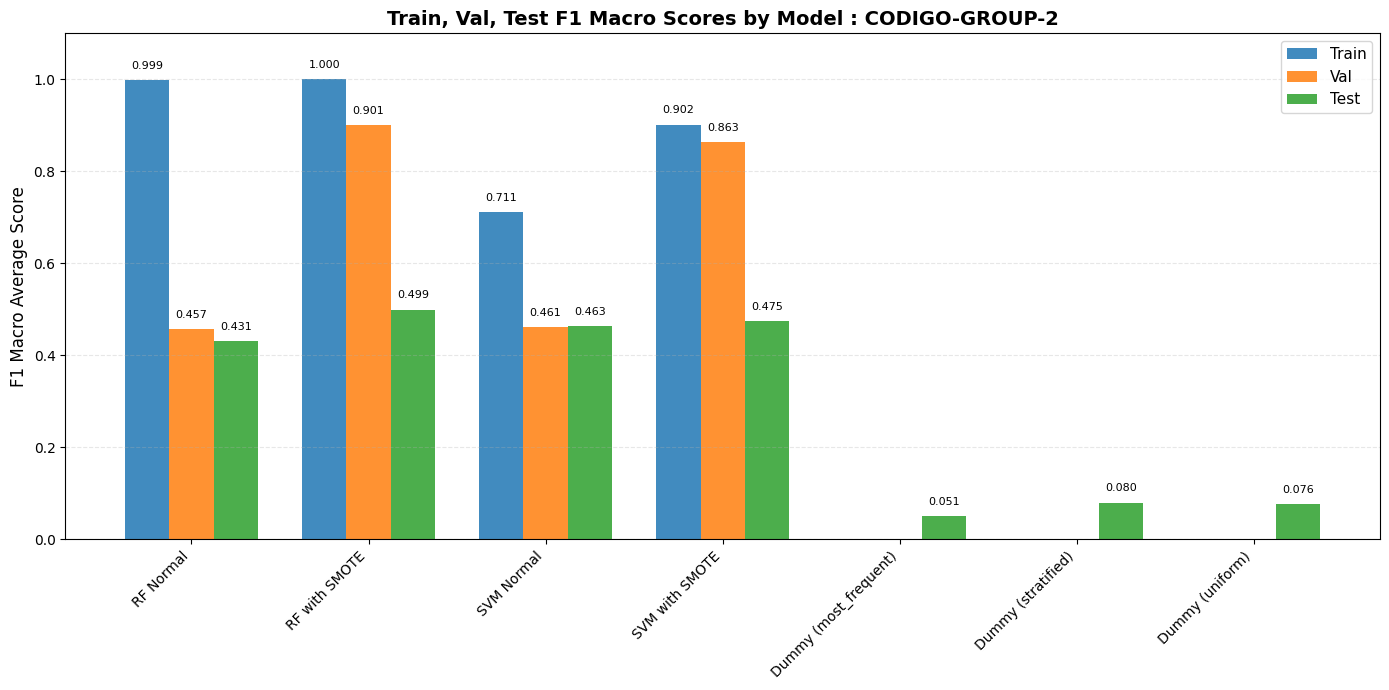

In [329]:
plot_comparison(models_info_with_dummy, group='CODIGO-GROUP-2')

## Codigo Group 1 

In [330]:
X_train, X_test, y_train, y_test, labels = load_train_test_data('CODIGO_GROUP_1')

train set distribution:
OBSERV_GROUP
Building               532
Agriculture            483
Forest                 342
Artificial Surfaces    154
Water                   32
Name: count, dtype: int64

 test distribution:
OBSERV_GROUP
Building               133
Agriculture            121
Forest                  85
Artificial Surfaces     39
Water                    8
Name: count, dtype: int64


## Normal RF 

Fitting 5 folds for each of 10 candidates, totalling 50 fits


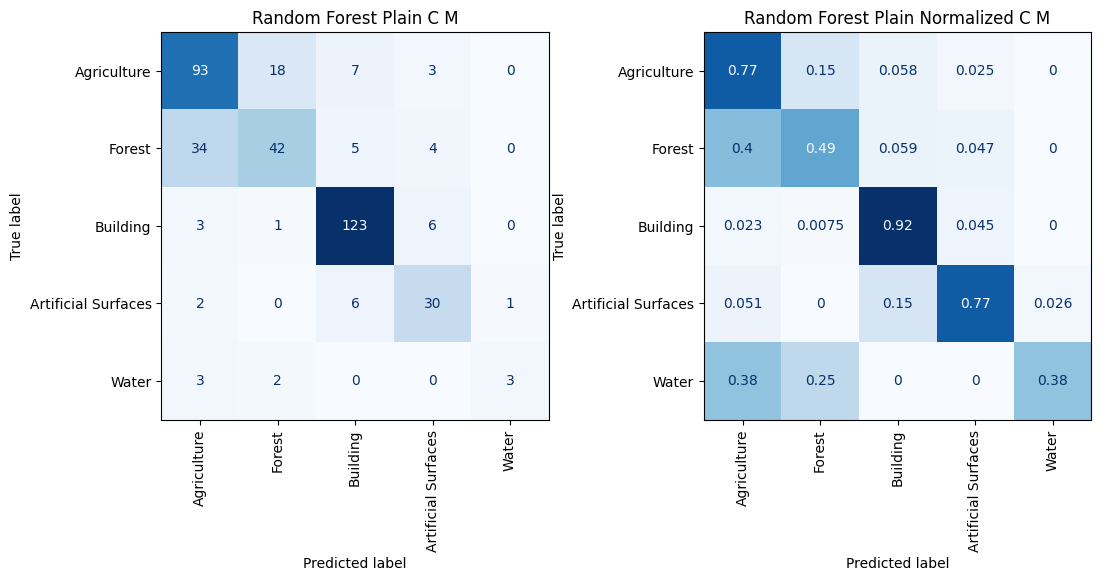


 Best Hyperparameters using cv: {'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 20, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 108}

 Best f1 score using cv: 0.6797240311999342

 best f1 val score 0.6797240311999342

 best f1 train score 0.9969866323284027
f1-macro-avg-test 0.6847295207237681
Testing Classification Report :
                      precision    recall  f1-score   support

        Agriculture       0.69      0.77      0.73       121
Artificial Surfaces       0.70      0.77      0.73        39
           Building       0.87      0.92      0.90       133
             Forest       0.67      0.49      0.57        85
              Water       0.75      0.38      0.50         8

           accuracy                           0.75       386
          macro avg       0.74      0.67      0.68       386
       weighted avg       0.75      0.75      0.75       386



In [331]:
random_search_cv_rf_normal= rf_hyperparameter_tuning(X_train, y_train)

testing_classification_accuracy_rf_normal, ac_dict_rf_normal = compute_accuracy(random_search_cv_rf_normal, X_test, y_test, labels, experiment_name='Random Forest Plain')

f1_macro_rf_normal_test = ac_dict_rf_normal['macro avg']['f1-score']

f1_macro_rf_normal_val_cv = random_search_cv_rf_normal.cv_results_['mean_test_score'][int(random_search_cv_rf_normal.best_index_)]
f1_macro_rf_normal_train_cv = random_search_cv_rf_normal.cv_results_['mean_train_score'][int(random_search_cv_rf_normal.best_index_)]


print("f1-macro-avg-test", f1_macro_rf_normal_test)

print("Testing Classification Report :\n", testing_classification_accuracy_rf_normal)


## Normal SVM

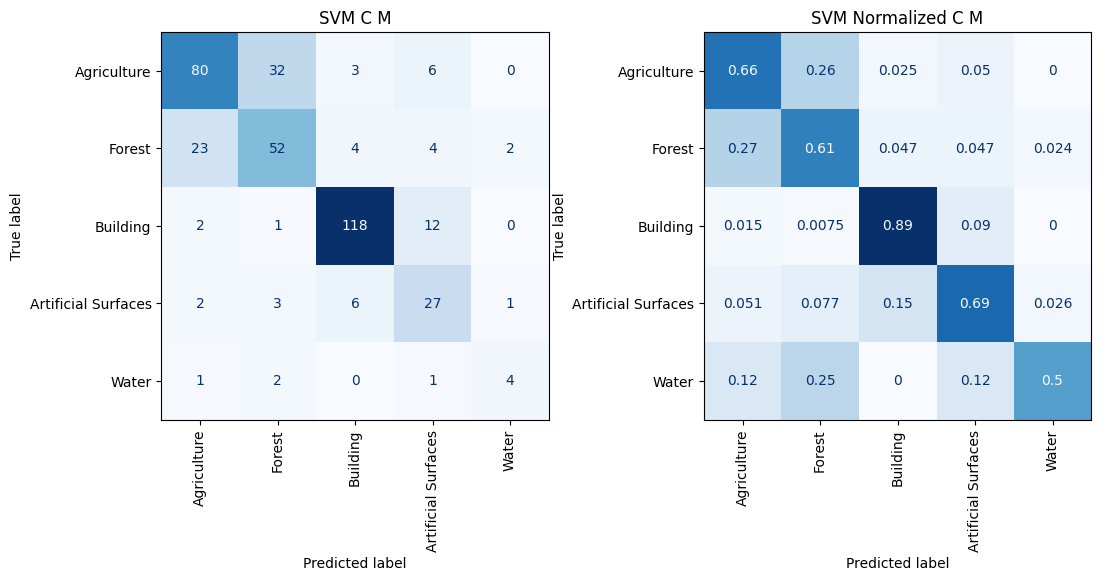


 Best Hyperparameters using cv: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}

 Best f1 score using cv: 0.6621512685140288

 best f1 val score 0.6621512685140288

 best f1 train score 0.8186686228546725
f1-macro-avg-test 0.6653979941848054
Testing Classification Report :
                      precision    recall  f1-score   support

        Agriculture       0.74      0.66      0.70       121
Artificial Surfaces       0.54      0.69      0.61        39
           Building       0.90      0.89      0.89       133
             Forest       0.58      0.61      0.59        85
              Water       0.57      0.50      0.53         8

           accuracy                           0.73       386
          macro avg       0.67      0.67      0.67       386
       weighted avg       0.74      0.73      0.73       386



In [332]:
best_model_svm_normal_cv, testing_classification_accuracy_svm_normal, ac_dict_svm_normal = run_svm_hyperparameter_tuning(X_train, y_train, X_test, y_test, labels)


f1_macro_svm_normal_test = ac_dict_svm_normal['macro avg']['f1-score']
f1_macro_svm_normal_val_cv = best_model_svm_normal_cv.cv_results_['mean_test_score'][int(best_model_svm_normal_cv.best_index_)]
f1_macro_svm_normal_train_cv = best_model_svm_normal_cv.cv_results_['mean_train_score'][int(best_model_svm_normal_cv.best_index_)]


print("f1-macro-avg-test", f1_macro_svm_normal_test)

print("Testing Classification Report :\n", testing_classification_accuracy_svm_normal)

## RF with SMOTE 

Fitting 5 folds for each of 10 candidates, totalling 50 fits


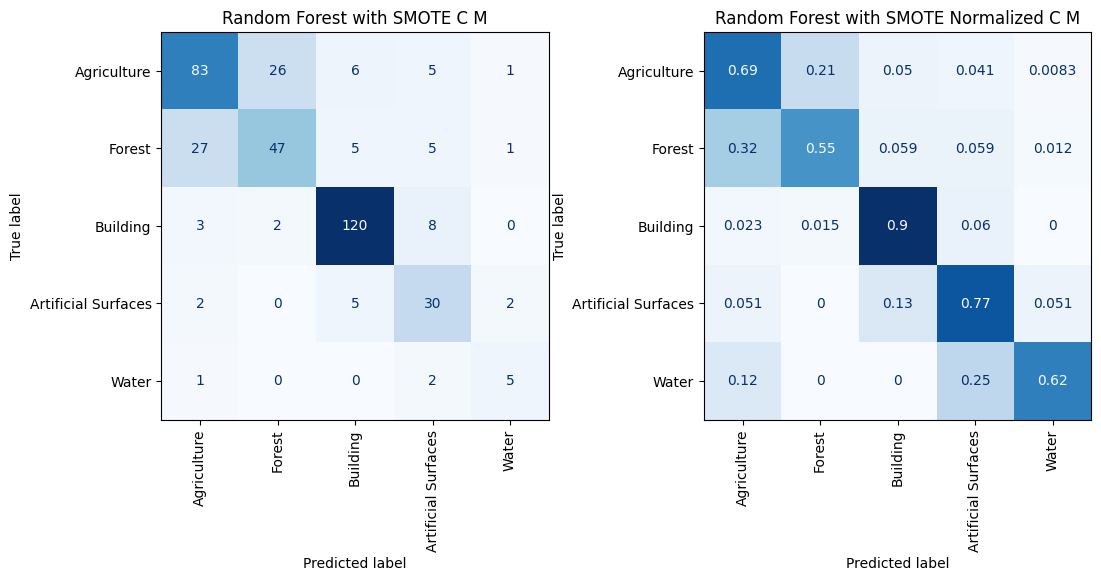


 Best Hyperparameters using cv: {'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_depth': 20, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 107}

 Best f1 score using cv: 0.8311709955087239

 best f1 val score 0.8311709955087239

 best f1 train score 0.9974630088012711
f1-macro-avg-test 0.6885015693933779
Testing Classification Report:
                      precision    recall  f1-score   support

        Agriculture       0.72      0.69      0.70       121
Artificial Surfaces       0.60      0.77      0.67        39
           Building       0.88      0.90      0.89       133
             Forest       0.63      0.55      0.59        85
              Water       0.56      0.62      0.59         8

           accuracy                           0.74       386
          macro avg       0.68      0.71      0.69       386
       weighted avg       0.74      0.74      0.74       386



In [333]:
from imblearn.over_sampling import SMOTE # source : https://medium.com/sfu-cspmp/surviving-in-a-random-forest-with-imbalanced-datasets-b98b963d52eb

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

random_search_cv_rf_with_smote= rf_hyperparameter_tuning(X_train_resampled, y_train_resampled)

testing_classification_accuracy_rf_with_smote, ac_dict_rf_with_smote = compute_accuracy(random_search_cv_rf_with_smote, X_test, y_test,labels, experiment_name='Random Forest with SMOTE')

f1_macro_rf_with_smote_test = ac_dict_rf_with_smote['macro avg']['f1-score']

f1_macro_rf_with_smote_val_cv = random_search_cv_rf_with_smote.cv_results_['mean_test_score'][int(random_search_cv_rf_with_smote.best_index_)]
f1_macro_rf_with_smote_train_cv = random_search_cv_rf_with_smote.cv_results_['mean_train_score'][int(random_search_cv_rf_with_smote.best_index_)]


print("f1-macro-avg-test", f1_macro_rf_with_smote_test)

print("Testing Classification Report:\n", testing_classification_accuracy_rf_with_smote)

# _ = plot_rf_feature_importances(random_search_cv_rf_with_smote.best_estimator_)

## SVM with SMOTE

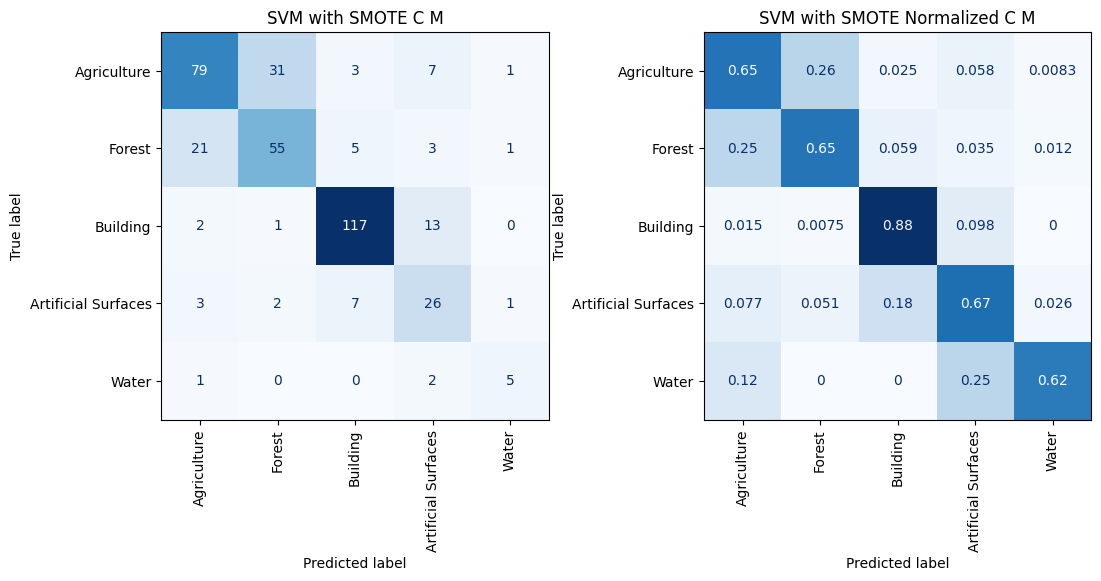


 Best Hyperparameters using cv: {'C': 6, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}

 Best f1 score using cv: 0.8139210781111453

 best f1 val score 0.8139210781111453

 best f1 train score 0.8739328403914308
f1-macro-avg-test 0.6828031592078063
Testing Classification Report :
                      precision    recall  f1-score   support

        Agriculture       0.75      0.65      0.70       121
Artificial Surfaces       0.51      0.67      0.58        39
           Building       0.89      0.88      0.88       133
             Forest       0.62      0.65      0.63        85
              Water       0.62      0.62      0.62         8

           accuracy                           0.73       386
          macro avg       0.68      0.69      0.68       386
       weighted avg       0.74      0.73      0.73       386



In [334]:
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

best_model_svm_with_smote, testing_classification_accuracy_svm_with_smote, ac_dict_svm_with_smote = run_svm_hyperparameter_tuning(X_train_resampled, y_train_resampled, X_test, y_test,labels, experiment_name='SVM with SMOTE')

f1_macro_svm_with_smote_test = ac_dict_svm_with_smote['macro avg']['f1-score']
f1_macro_svm_with_smote_val_cv = best_model_svm_with_smote.cv_results_['mean_test_score'][int(best_model_svm_with_smote.best_index_)]
f1_macro_svm_with_smote_train_cv = best_model_svm_with_smote.cv_results_['mean_train_score'][int(best_model_svm_with_smote.best_index_)]


print("f1-macro-avg-test", f1_macro_svm_with_smote_test)

print("Testing Classification Report :\n", testing_classification_accuracy_svm_with_smote)

In [335]:
models_info = [
    {
        "name": "RF Normal",
        "model": random_search_cv_rf_normal.best_estimator_,
        "train_score": f1_macro_rf_normal_train_cv,
        "val_score": f1_macro_rf_normal_val_cv,
        "test_score": f1_macro_rf_normal_test,
    },
    {
        "name": "RF with SMOTE",
        "model": random_search_cv_rf_with_smote.best_estimator_,
        "train_score": f1_macro_rf_with_smote_train_cv,
        "val_score": f1_macro_rf_with_smote_val_cv,
        "test_score": f1_macro_rf_with_smote_test,
    },
    {
        "name": "SVM Normal",
        "model": best_model_svm_normal_cv.best_estimator_,
        "scaler": StandardScaler(),
        "train_score": f1_macro_svm_normal_train_cv,
        "val_score": f1_macro_svm_normal_val_cv,
        "test_score": f1_macro_svm_normal_test,
    },
    {
        "name": "SVM with SMOTE",
        "model": best_model_svm_with_smote.best_estimator_,
        "scaler": StandardScaler(),
        "train_score": f1_macro_svm_with_smote_train_cv,
        "val_score": f1_macro_svm_with_smote_val_cv,
        "test_score": f1_macro_svm_with_smote_test,
    },
]

dummy_f1_scores = get_dummy_f1_scores(X_train, y_train, X_test, y_test)

models_info_with_dummy = models_info + [
    {
        "name": "Dummy (most_frequent)",
        "model": None,
        "train_score": 0,
        "val_score": 0,
        "test_score": dummy_f1_scores['most_frequent'],
    },
    {
        "name": "Dummy (stratified)",
        "model": None,
        "train_score": 0,
        "val_score": 0,
        "test_score": dummy_f1_scores['stratified'],
    },
    {
        "name": "Dummy (uniform)",
        "model": None,
        "train_score": 0,
        "val_score": 0,
        "test_score": dummy_f1_scores['uniform'],
    },
]


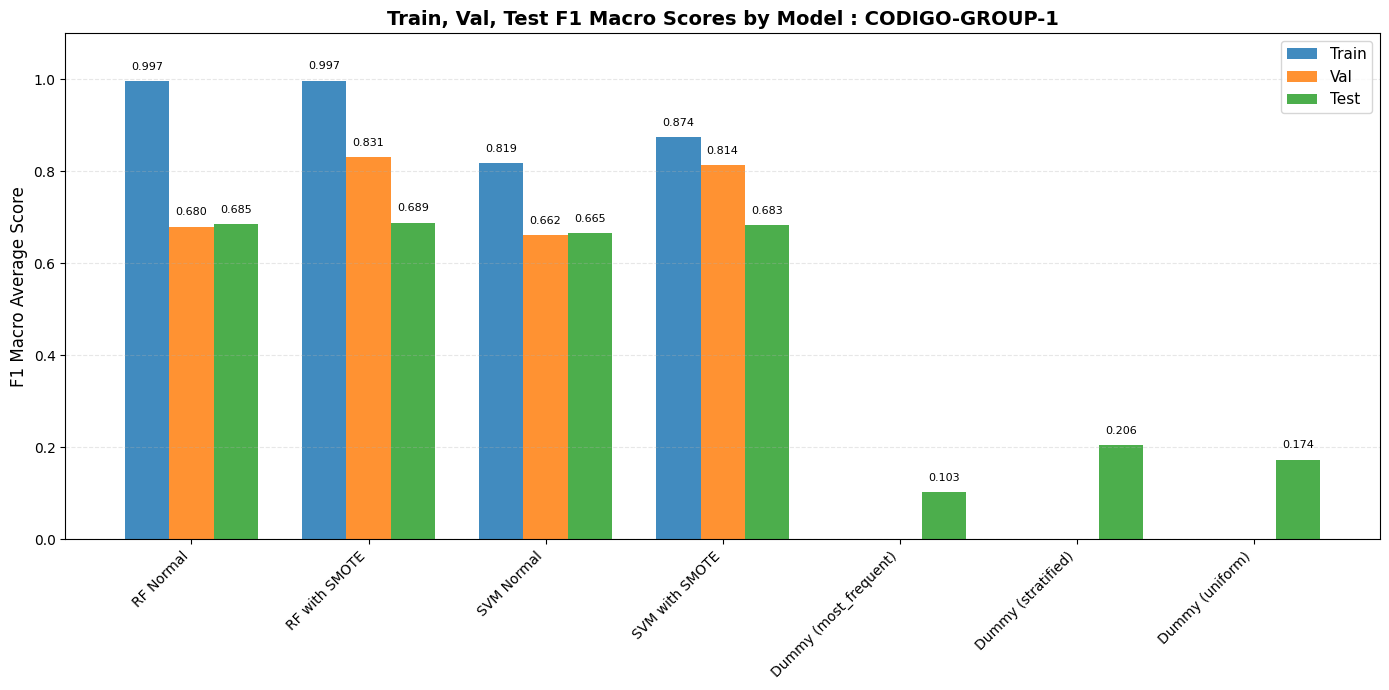

In [336]:
plot_comparison(models_info_with_dummy)

### Boruta feature selection

In [337]:
from boruta import BorutaPy

boruta = BorutaPy(random_search_cv_rf_normal.best_estimator_, n_estimators='auto', verbose=0, random_state=1)

boruta.fit(X_train, y_train) # source : audrey & https://towardsdatascience.com/feature-selection-with-boruta-in-python-676e3877e596/

,estimator,RandomForestC...t 0x11B79F840)
,n_estimators,'auto'
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,random_state,RandomState(M...at 0x11B79F840
,verbose,0
,early_stopping,False
,n_iter_no_change,20
,n_estimators,32


In [338]:
# check selected features
boruta.support_

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True])

In [339]:
boruta.ranking_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1])

In [340]:
boruta_features = [f for f,s in zip(features, boruta.support_) if s]
print(boruta_features)
print(len(boruta_features))
print(len(features))
print(set(features) - set(boruta_features))

['r_mean', 'r_median', 'r_std', 'r_var', 'g_mean', 'g_median', 'g_std', 'g_var', 'b_mean', 'b_median', 'b_var', 'b_std', 'eccentricity', 'mean_intensity', 'perimeter', 'compactness', 'shape_index', 'area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']
21
22
{'solidity'}


Fitting 5 folds for each of 10 candidates, totalling 50 fits


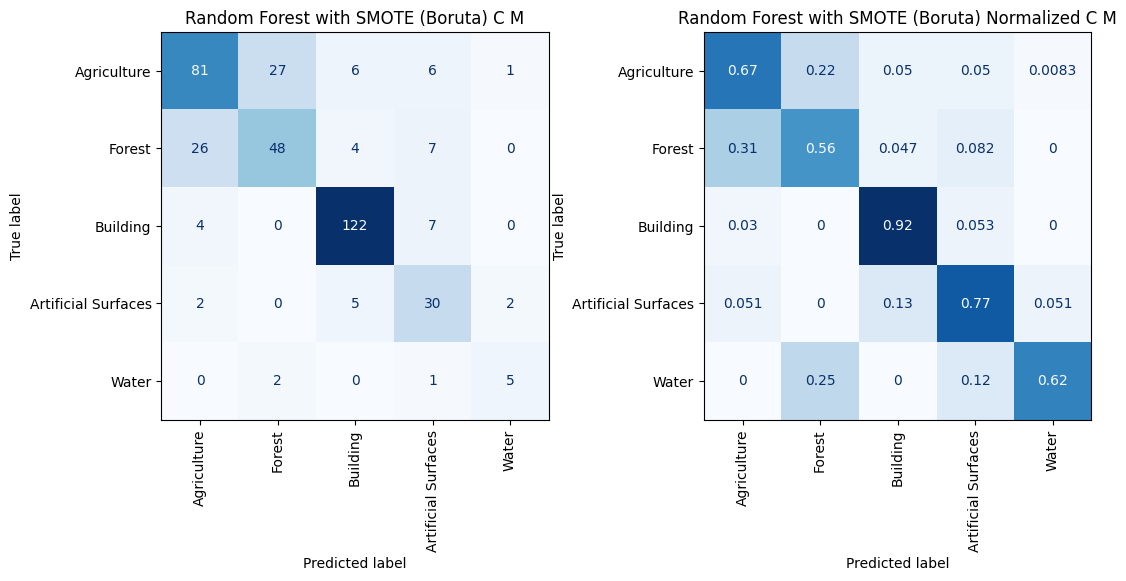


 Best Hyperparameters using cv: {'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 20, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 108}

 Best f1 score using cv: 0.8357116064447687

 best f1 val score 0.8357116064447687

 best f1 train score 0.9988722419945393
f1-macro-avg-test boruta  0.696054131054131
f1-macro-avg-test difference than normal 0.011324610330362916
Testing Classification Report:
                      precision    recall  f1-score   support

        Agriculture       0.72      0.67      0.69       121
Artificial Surfaces       0.59      0.77      0.67        39
           Building       0.89      0.92      0.90       133
             Forest       0.62      0.56      0.59        85
              Water       0.62      0.62      0.62         8

           accuracy                           0.74       386
          macro avg       0.69      0.71      0.70       386
       weighted avg       0.74      0.74     

In [341]:
from imblearn.over_sampling import SMOTE # source : https://medium.com/sfu-cspmp/surviving-in-a-random-forest-with-imbalanced-datasets-b98b963d52eb

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train[boruta_features], y_train)

random_search_cv_rf_with_smote= rf_hyperparameter_tuning(X_train_resampled, y_train_resampled)

testing_classification_accuracy_rf_with_smote, ac_dict_rf_with_smote = compute_accuracy(random_search_cv_rf_with_smote, X_test[boruta_features], y_test,labels, experiment_name='Random Forest with SMOTE (Boruta)')
f1_macro_rf_with_smote_test_boruta = ac_dict_rf_with_smote['macro avg']['f1-score']

f1_macro_rf_with_smote_val_cv_boruta = random_search_cv_rf_with_smote.cv_results_['mean_test_score'][int(random_search_cv_rf_with_smote.best_index_)]
f1_macro_rf_with_smote_train_cv_boruta = random_search_cv_rf_with_smote.cv_results_['mean_train_score'][int(random_search_cv_rf_with_smote.best_index_)]


print("f1-macro-avg-test boruta ", f1_macro_rf_with_smote_test_boruta)
print("f1-macro-avg-test difference than normal", f1_macro_rf_with_smote_test_boruta - f1_macro_rf_normal_test)

print("Testing Classification Report:\n", testing_classification_accuracy_rf_with_smote)

# _ = plot_rf_feature_importances(random_search_cv_rf_with_smote.best_estimator_)